In [1]:
import os
import random

import torch
import torchvision.datasets as dset
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from torch.distributions import Bernoulli

os.chdir("..")  # Run in project directory

# Deep Reinforcement Learning _in Action_
## MNIST Genetic Algorithm

Setup a directory to store the MNIST dataset/

In [2]:
root = "./data"
if not os.path.exists(root):
    print("Data directory missing, creating directory...")
    os.mkdir(root)

Setup a transformer to normalize the data.

In [3]:
trans = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))]
)

In [4]:
train_set = dset.MNIST(root=root, train=True, transform=trans, download=True)
test_set = dset.MNIST(root=root, train=False, transform=trans, download=True)

In [5]:
batch_size = 100

train_loader = torch.utils.data.DataLoader(
    dataset=train_set, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_set, batch_size=batch_size, shuffle=False
)

We define a simple linear classifier (or you can think of it as a single layer neural network). It simply multiplies a weight/parameter matrix by the input vector and applies a softmax.

In [6]:
x = next(iter(train_loader))[0]

In [7]:
x = x.reshape(batch_size, 784)

In [8]:
class Individual:
    def __init__(self, param, fitness=0):
        self.param = param
        self.fitness = fitness

In [9]:
def model(x, W):
    return torch.nn.Softmax(dim=-1)(x @ W)

In [10]:
model(x, torch.rand(784, 10))

tensor([[1.2070e-02, 1.4346e-03, 1.0853e-06, 2.8025e-04, 1.8480e-01, 3.4319e-03,
         2.2125e-04, 4.5235e-01, 1.2819e-01, 2.1722e-01],
        [7.6691e-01, 2.0412e-06, 3.2562e-06, 3.3060e-04, 6.3592e-05, 5.9863e-05,
         1.3692e-05, 1.5711e-01, 2.2289e-02, 5.3214e-02],
        [5.3130e-01, 6.2211e-05, 1.3555e-06, 1.1587e-03, 7.2567e-03, 4.9178e-05,
         6.3727e-05, 9.4015e-03, 2.2753e-02, 4.2795e-01],
        [2.8970e-01, 2.0724e-02, 2.2211e-03, 1.1163e-02, 1.7182e-03, 1.5381e-02,
         2.4128e-02, 4.3985e-02, 1.2297e-01, 4.6801e-01],
        [2.9738e-02, 2.4554e-02, 1.5832e-05, 1.6355e-02, 1.1028e-02, 3.2341e-02,
         3.7312e-04, 7.4678e-02, 2.8592e-01, 5.2500e-01],
        [6.1409e-02, 7.6444e-05, 1.0062e-07, 5.8053e-03, 1.1818e-02, 1.8877e-02,
         1.0757e-03, 5.1231e-02, 8.0757e-01, 4.2141e-02],
        [2.3068e-02, 2.0257e-05, 6.2020e-05, 3.2384e-03, 7.3469e-06, 6.2537e-04,
         2.2894e-05, 3.3970e-01, 4.3711e-01, 1.9615e-01],
        [8.5444e-03, 1.2177

In [11]:
def spawn_population(param_size=(784, 10), pop_size=1000):
    return [Individual(torch.randn(*param_size)) for i in range(pop_size)]

In [12]:
loss_fn = torch.nn.CrossEntropyLoss()

In [13]:
random.randint(0, 10)

9

In [14]:
def evaluate_population(pop):
    avg_fit = 0  # avg population fitness
    for individual in pop:
        x, y = next(iter(train_loader))
        pred = model(x.reshape(batch_size, 784), individual.param)
        loss = loss_fn(pred, y)
        fit = loss
        individual.fitness = 1.0 / fit
        avg_fit += fit
    avg_fit = avg_fit / len(pop)
    return pop, avg_fit

In [15]:
def recombine(x1, x2):  # x1,x2 : Individual
    w1 = x1.param.view(-1)  # flatten
    w2 = x2.param.view(-1)
    cross_pt = random.randint(0, w1.shape[0])
    child1 = torch.zeros(w1.shape)
    child2 = torch.zeros(w1.shape)
    child1[0:cross_pt] = w1[0:cross_pt]
    child1[cross_pt:] = w2[cross_pt:]
    child2[0:cross_pt] = w2[0:cross_pt]
    child2[cross_pt:] = w1[cross_pt:]
    child1 = child1.reshape(784, 10)
    child2 = child2.reshape(784, 10)
    c1 = Individual(child1)
    c2 = Individual(child2)
    return [c1, c2]

In [16]:
def mutate(pop, mut_rate=0.01):
    param_shape = pop[0].param.shape
    l = torch.zeros(*param_shape)
    l[:] = mut_rate
    m = Bernoulli(l)
    for individual in pop:
        mut_vector = m.sample() * torch.randn(*param_shape)
        individual.param = mut_vector + individual.param
    return pop

In [17]:
def seed_next_population(pop, pop_size=1000, mut_rate=0.01):
    new_pop = []
    while len(new_pop) < pop_size:  # until new pop is full
        parents = random.choices(pop, k=2, weights=[x.fitness for x in pop])
        offspring = recombine(parents[0], parents[1])
        new_pop.extend(offspring)
    new_pop = mutate(new_pop, mut_rate)
    return new_pop

In [18]:
pop = spawn_population()

In [19]:
%%time
pop, avg_fit = evaluate_population(pop)

CPU times: total: 2min 35s
Wall time: 9.8 s


In [20]:
new_pop = seed_next_population(pop)

In [21]:
len(new_pop)

1000

Now we need to spawn a population of weight matrices, run the model using the different individuals, calculate the loss for each one, and then breed the ones with the highest fitness score (lowest loss).

In [22]:
num_generations = 50
population_size = 100
mutation_rate = 0.001

### Main Evolution (Training) Loop

In [23]:
pop_fit = []
pop = spawn_population(pop_size=population_size)  # initial population
for gen in range(num_generations):
    # trainning
    pop, avg_fit = evaluate_population(pop)
    pop_fit.append(avg_fit)  # record population average fitness
    new_pop = seed_next_population(
        pop, pop_size=population_size, mut_rate=mutation_rate
    )
    pop = new_pop

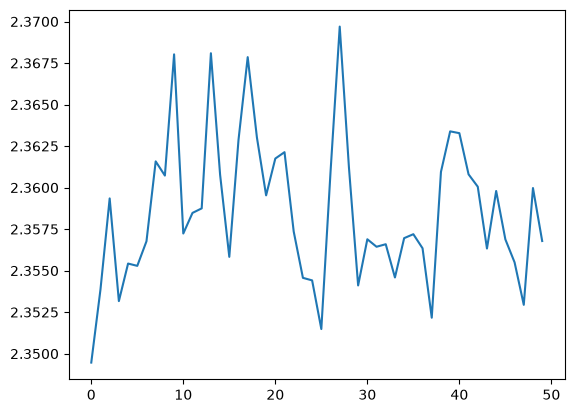

In [24]:
plt.plot(pop_fit)

In [25]:
avg_loss = 0
for i in range(len(pop)):
    x, y = next(iter(train_loader))
    pred = model(x.reshape(batch_size, 784), pop[i].param)
    loss = loss_fn(pred, y)
    avg_loss += loss
avg_loss /= len(pop)
print(avg_loss)

tensor(2.3573)


Avg Loss new pop: 2.3336
Avg Loss after 10 gens: 2.3435

In [26]:
evaluate_population(pop)
pop.sort(key=lambda x: x.fitness, reverse=True)
print(pop[0].fitness)

tensor(0.4432)


In [27]:
def model_accuracy(dataset, model_params):
    correct, total = 0, 0
    for x, y in dataset:
        pred = model(x.reshape(batch_size, 784), model_params)
        pred = pred.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    accuracy = correct / total
    print(f"Accuracy: {accuracy:.2%}")


model_accuracy(train_loader, pop[0].param)
model_accuracy(test_loader, pop[0].param)

Accuracy: 15.41%
Accuracy: 14.82%


## Train with gradient-descent (comparison)

In [28]:
p = torch.randn(784, 10, requires_grad=True)
optim = torch.optim.Adam(lr=1e-3, params=[p])

In [29]:
loss_list = []
for epoch in range(50):
    for x, y in train_loader:
        optim.zero_grad()
        pred = model(x.reshape(batch_size, 784), p)
        loss = loss_fn(pred, y)

        loss.backward()
        optim.step()

        loss_list.append(loss.item())

    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 2.1560
Epoch 2: loss = 2.1590
Epoch 3: loss = 2.1684
Epoch 4: loss = 2.1160
Epoch 5: loss = 2.0816
Epoch 6: loss = 1.9370
Epoch 7: loss = 2.0726
Epoch 8: loss = 2.0310
Epoch 9: loss = 1.9188
Epoch 10: loss = 1.8766
Epoch 11: loss = 1.9015
Epoch 12: loss = 1.8443
Epoch 13: loss = 1.9077
Epoch 14: loss = 2.0270
Epoch 15: loss = 1.9845
Epoch 16: loss = 1.8692
Epoch 17: loss = 1.8195
Epoch 18: loss = 1.8768
Epoch 19: loss = 1.8880
Epoch 20: loss = 1.8983
Epoch 21: loss = 1.9116
Epoch 22: loss = 1.9471
Epoch 23: loss = 1.9404
Epoch 24: loss = 1.8739
Epoch 25: loss = 1.9764
Epoch 26: loss = 1.8983
Epoch 27: loss = 1.8963
Epoch 28: loss = 1.9714
Epoch 29: loss = 1.8076
Epoch 30: loss = 1.8674
Epoch 31: loss = 1.7829
Epoch 32: loss = 1.8115
Epoch 33: loss = 1.7108
Epoch 34: loss = 1.8408
Epoch 35: loss = 1.7171
Epoch 36: loss = 1.8449
Epoch 37: loss = 1.8216
Epoch 38: loss = 1.8402
Epoch 39: loss = 1.8269
Epoch 40: loss = 1.7754
Epoch 41: loss = 1.7999
Epoch 42: loss = 1.7439
E

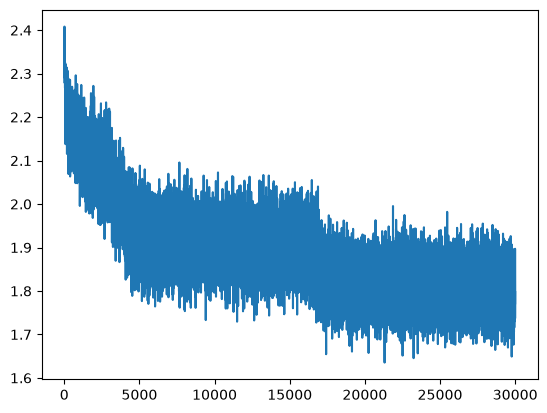

In [30]:
plt.plot(loss_list)

In [31]:
model_accuracy(train_loader, p)
model_accuracy(test_loader, p)

Accuracy: 65.32%
Accuracy: 63.80%
